# 01 — Exploratory Data Analysis

Purpose: establish, from the raw data itself (not assumptions), the structural
facts that constrain every later modeling decision — the split strategy, the
windowing scheme, and what a "sequence" can honestly mean for this dataset.

Dataset: `data/raw/FINAL_DATASET_allpara.xlsx` — 300 rows, 16 columns, daily
meteorological reanalysis variables + lag temperatures for Kolkata, reused from
the prior classical-ML internship (see `reports/` for the full comparison).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    load_raw, detect_bursts, burst_summary, check_lag_leakage,
    block_chronological_split, LAG_COLS, STATIC_FEATURE_COLS, TARGET_COLS,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

df = load_raw()
print(df.shape)
df.dtypes

(300, 16)


Date                          datetime64[ns]
Hr                                     int64
specific_humidity_500hPa             float64
geopotential_height_500hPa           float64
surface_sensible_heat_flux           float64
surface_latent_heat_flux             float64
Wind_500hPa_ms                       float64
OLR_Wm2                              float64
TCC                                  float64
T(i-1)                               float64
T(i-2)                               float64
T(i-3)                               float64
T(i-4)                               float64
dbt                                  float64
wbt                                  float64
Urban_Footprint                      float64
dtype: object

In [2]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df['Date'].duplicated().sum(), "of", len(df), "rows -",
      "confirms one row per calendar day (the 'Hr' column is a same-day attribute,")
print("not a marker of multiple daily observations).")

Missing values per column:
T(i-1)    1
dtype: int64

Duplicate rows: 0
Duplicate dates: 0 of 300 rows - confirms one row per calendar day (the 'Hr' column is a same-day attribute,
not a marker of multiple daily observations).


## Is this a continuous daily time series?

Sorting by `Date`, check the gap (in days) between consecutive rows. If the data
were one continuous daily series, every gap would be exactly 1 day.


In [3]:
gaps = df.sort_values('Date')['Date'].diff().dt.days.dropna()
print(gaps.describe())
print()
print("Rows where the gap to the previous row is NOT 1 day:", (gaps != 1).sum(),
      "out of", len(gaps), "gaps")

count     299.000000
mean       49.307692
std       196.973848
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      1817.000000
Name: Date, dtype: float64

Rows where the gap to the previous row is NOT 1 day: 70 out of 299 gaps


**Not continuous.** Most transitions are large jumps, not single-day steps.
The data is a set of short, disjoint "bursts" of consecutive days scattered
across 1980–2020 — almost certainly individual multi-day heat-event windows
selected for study, not a continuous record. This must be respected everywhere
temporal order is used downstream.


In [4]:
df_b = detect_bursts(df)
bsum = burst_summary(df_b)
print("Number of bursts:", len(bsum))
print()
print("Burst length distribution:")
print(bsum['n_rows'].value_counts().sort_index())
print()
print("Rows sitting in bursts of length >= 3:", bsum.loc[bsum.n_rows >= 3, 'n_rows'].sum(),
      "/", len(df), f"({bsum.loc[bsum.n_rows >= 3, 'n_rows'].sum() / len(df):.0%})")
print("Rows sitting in bursts of length >= 5:", bsum.loc[bsum.n_rows >= 5, 'n_rows'].sum(),
      "/", len(df), f"({bsum.loc[bsum.n_rows >= 5, 'n_rows'].sum() / len(df):.0%})")
print("Max burst length:", bsum['n_rows'].max())

Number of bursts: 71

Burst length distribution:
n_rows
1      1
2      2
3     27
4     20
5      8
6      4
7      5
8      2
9      1
10     1
Name: count, dtype: int64

Rows sitting in bursts of length >= 3: 295 / 300 (98%)
Rows sitting in bursts of length >= 5: 134 / 300 (45%)
Max burst length: 10


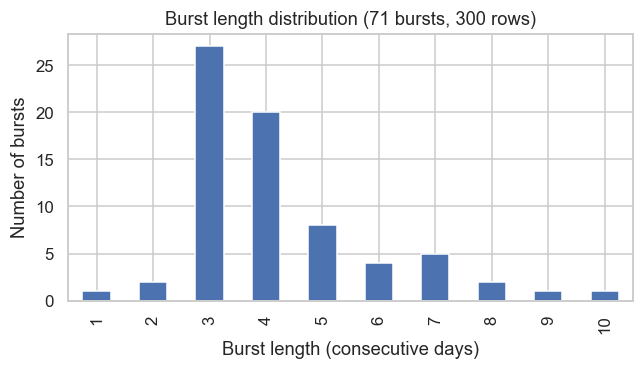

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
bsum['n_rows'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Burst length (consecutive days)')
ax.set_ylabel('Number of bursts')
ax.set_title('Burst length distribution (71 bursts, 300 rows)')
plt.tight_layout()
plt.show()

**Implication for window length `k`:** a genuine sliding window of length `k`
(k prior days -> next day) can only be formed within a burst of length >= k+1. The
table below (computed properly in `notebooks/02_preprocessing_windowing.ipynb`)
previews how much data survives at each candidate `k` — this is why the modeling
design uses the dataset's own precomputed lag columns `T(i-1)..T(i-4)` as the
sequence axis (available for all 300 rows, already leakage-checked — see below)
rather than re-deriving raw multi-day windows from the burst structure, which
would discard 40-70% of the data depending on `k`.


In [6]:
for k in (2, 3, 4):
    usable = bsum.loc[bsum.n_rows > k, 'n_rows'].apply(lambda n, k=k: n - k).sum()
    print(f"k={k}: burst-derived raw windows available = {usable} / 300 rows "
          f"({usable/300:.0%})")

k=2: burst-derived raw windows available = 159 / 300 rows (53%)
k=3: burst-derived raw windows available = 91 / 300 rows (30%)
k=4: burst-derived raw windows available = 50 / 300 rows (17%)


## Lag-feature leakage check

The dataset ships `T(i-1)..T(i-4)` as precomputed lag temperatures. Verify they
actually equal the DBT of the preceding day *within the same burst* — if the
internship (or the raw ERA5 extraction pipeline) had made an indexing mistake
here, it would silently leak the target into the features.


In [7]:
mismatches = check_lag_leakage(df_b)
print("T(i-1) vs previous-row dbt mismatches (same burst):", len(mismatches))
assert len(mismatches) == 0, "Lag feature leakage detected - investigate before modeling"
print("Confirmed: lag features are internally consistent. Safe to use as-is.")

T(i-1) vs previous-row dbt mismatches (same burst): 0
Confirmed: lag features are internally consistent. Safe to use as-is.


## Target distributions: DBT and WBT


              dbt         wbt
count  300.000000  300.000000
mean    35.011333   29.513667
std      2.175619    1.301059
min     28.400000   25.000000
25%     33.800000   29.200000
50%     35.200000   29.800000
75%     36.600000   30.000000
max     40.200000   32.000000


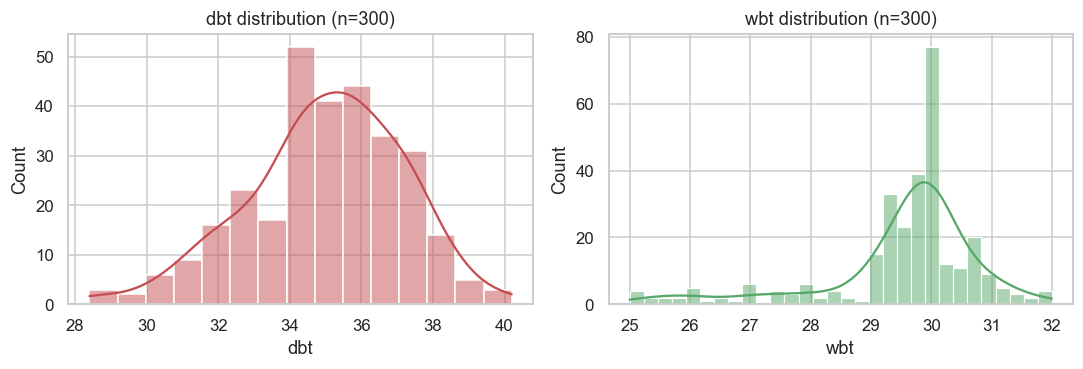

In [8]:
print(df[TARGET_COLS].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, color in zip(axes, TARGET_COLS, ['#C44E52', '#55A868']):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'{col} distribution (n=300)')
plt.tight_layout()
plt.show()

## Feature correlation structure

Correlation among predictors and with both targets — informs which engineered
features (e.g. the lag block) matter most, and flags multicollinearity relevant
to the CNN-LSTM's shared-backbone design.


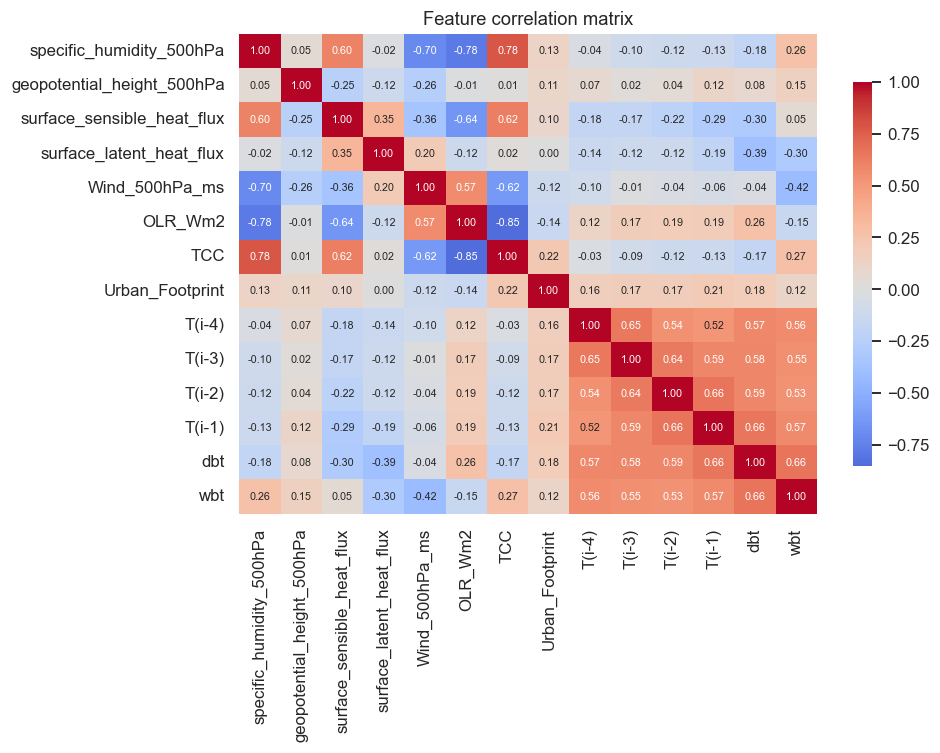

In [9]:
corr_cols = STATIC_FEATURE_COLS + LAG_COLS + TARGET_COLS
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [10]:
print("Correlation with dbt, sorted:")
print(corr['dbt'].drop(['dbt', 'wbt']).sort_values(ascending=False))
print()
print("Correlation with wbt, sorted:")
print(corr['wbt'].drop(['dbt', 'wbt']).sort_values(ascending=False))

Correlation with dbt, sorted:
T(i-1)                        0.656122
T(i-2)                        0.589435
T(i-3)                        0.580958
T(i-4)                        0.574143
OLR_Wm2                       0.264508
Urban_Footprint               0.179881
geopotential_height_500hPa    0.083486
Wind_500hPa_ms               -0.040350
TCC                          -0.174614
specific_humidity_500hPa     -0.178195
surface_sensible_heat_flux   -0.296840
surface_latent_heat_flux     -0.385265
Name: dbt, dtype: float64

Correlation with wbt, sorted:
T(i-1)                        0.566491
T(i-4)                        0.561269
T(i-3)                        0.551012
T(i-2)                        0.532854
TCC                           0.271796
specific_humidity_500hPa      0.263145
geopotential_height_500hPa    0.150063
Urban_Footprint               0.116508
surface_sensible_heat_flux    0.050451
OLR_Wm2                      -0.154877
surface_latent_heat_flux     -0.298295
Wind_500hPa_ms  

## Chronological, burst-aware split — sanity check

Confirms `src.data.block_chronological_split` produces non-overlapping,
chronologically ordered train/val/test sets with no burst split across a
boundary (the internship used a *random* 80:20 split; this project uses a
stricter chronological one — see `reports/phase2_design.md`).


In [11]:
train_df, val_df, test_df = block_chronological_split(df_b)
print(f"train: {len(train_df):3d} rows | {train_df.Date.min().date()} -> {train_df.Date.max().date()} | "
      f"{train_df.burst_id.nunique()} bursts")
print(f"val:   {len(val_df):3d} rows | {val_df.Date.min().date()} -> {val_df.Date.max().date()} | "
      f"{val_df.burst_id.nunique()} bursts")
print(f"test:  {len(test_df):3d} rows | {test_df.Date.min().date()} -> {test_df.Date.max().date()} | "
      f"{test_df.burst_id.nunique()} bursts")
print()
print(f"Split fractions: train {len(train_df)/300:.1%}, val {len(val_df)/300:.1%}, test {len(test_df)/300:.1%}")

train: 210 rows | 1980-04-20 -> 2005-06-19 | 49 bursts
val:    46 rows | 2005-08-28 -> 2014-08-22 | 11 bursts
test:   44 rows | 2015-05-21 -> 2020-08-31 | 11 bursts

Split fractions: train 70.0%, val 15.3%, test 14.7%


## Summary of findings that drive the Phase 2 design

1. **Non-contiguous data**: 300 rows form 71 disjoint bursts of 1-10 consecutive
   days across 1980-2020, not one continuous series. Windowing/splitting must
   respect burst boundaries.
2. **Lag features are trustworthy**: `T(i-1)..T(i-4)` verified against the raw
   burst structure with zero mismatches — safe to use as the model's temporal
   axis.
3. **Raw re-derived windows are data-expensive**: a length-4 raw sliding window
   would use well under half the rows; the precomputed lag block gets full use
   of all 300 rows instead.
4. **Targets are well-behaved, low-variance**: DBT and WBT are both roughly
   unimodal with modest spread — consistent with the internship's finding that
   a regularized linear model (Ridge) was competitive for DBT.
5. **A stricter split is possible and used here**: chronological, burst-aware,
   vs. the internship's random 80:20 split.
